# 🌸 Ejercicio: Clasificación de Iris con MLflow

## 🎯 Objetivos del Ejercicio

En este ejercicio práctico aprenderás a:

1. **Trabajar con un problema de clasificación** multiclase
2. **Aplicar MLflow** a un modelo de árbol de decisión
3. **Registrar experimentos** de forma profesional
4. **Evaluar y comparar** diferentes configuraciones
5. **Crear visualizaciones** para clasificación

---

## 🌺 El Dataset Iris

El **Iris Dataset** es uno de los datasets más famosos en Machine Learning, introducido por Ronald Fisher en 1936.

### 📊 Características del Dataset

| Aspecto | Descripción |
|---------|-------------|
| **Muestras** | 150 flores (50 por clase) |
| **Características** | 4 medidas físicas (cm) |
| **Clases** | 3 especies de iris |
| **Tipo** | Clasificación multiclase |
| **Dificultad** | ⭐⭐ (Principiante) |

### 🌸 Las 3 Especies de Iris

1. **Iris Setosa** (Clase 0)
2. **Iris Versicolor** (Clase 1)
3. **Iris Virginica** (Clase 2)

### 📏 Las 4 Características

1. **Sepal Length** (Longitud del sépalo)
2. **Sepal Width** (Ancho del sépalo)
3. **Petal Length** (Longitud del pétalo)
4. **Petal Width** (Ancho del pétalo)

---

## 🎯 Tu Misión

Construir un **Árbol de Decisión** que pueda clasificar correctamente las especies de iris basándose en sus medidas físicas, y documentar todo el proceso con MLflow.

---

## 🚀 ¡Empecemos!

In [ ]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

# mlflow.set_tracking_uri("databricks")
# mlflow.set_registry_uri("databricks")

# ⚠️ IMPORTANTE: Cambia esto por tu email de Databricks
email = '202625679@alu.comillas.edu'  # Ejemplo: 'nombre.apellido@ejemplo.com'

# Validar que el email no esté vacío
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
    print("   Cambia la variable 'email' por tu email de Databricks")
else:
    # Configurar el experimento
    experiment_name = f"/Users/{email}/4-ejercicio-the-irish"
    mlflow.set_experiment(experiment_name)

    print("=" * 60)
    print("✅ MLflow configurado correctamente")
    print("=" * 60)
    print(f"📊 Experimento: {experiment_name}")
    print(f"🌸 Dataset: Iris (Clasificación)")
    print(f"🤖 Modelo: Decision Tree Classifier")
    print("=" * 60)

c:\Users\Byadr\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ MLflow configurado correctamente
📊 Experimento: /Users/202625679@alu.comillas.edu/4-ejercicio-the-irish
🌸 Dataset: Iris (Clasificación)
🤖 Modelo: Decision Tree Classifier


## ⚙️ Paso 1: Configuración de MLflow

Configuramos el experimento donde se registrarán todas las ejecuciones.

**🔴 IMPORTANTE**: Cambia el email vacío por tu email de Databricks.

## 📚 Paso 2: Importar Librerías

Importamos todas las herramientas necesarias para clasificación.

In [2]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MLflow para tracking
import mlflow
import mlflow.sklearn

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")
print("   - MLflow: Listo para tracking")
print("   - Scikit-learn: Modelos y métricas")
print("   - Matplotlib & Seaborn: Visualizaciones")

✅ Todas las librerías importadas correctamente
   - MLflow: Listo para tracking
   - Scikit-learn: Modelos y métricas
   - Matplotlib & Seaborn: Visualizaciones


## 🌺 Paso 3: Cargar y Explorar el Dataset Iris

Cargaremos el famoso dataset de flores Iris y exploraremos sus características.

In [3]:
# Cargo el dataset de iris
dataset = datasets.load_iris()

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['species'] = dataset.target

print("Shape:", df.shape)
print("Clases:", dataset.target_names)
print()
print(df['species'].value_counts())
print()
print(df.describe())

df.head()

Shape: (150, 5)
Clases: ['setosa' 'versicolor' 'virginica']

species
0    50
1    50
2    50
Name: count, dtype: int64

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 📊 Visualización Exploratoria del Dataset

Visualicemos las relaciones entre las características para entender mejor los datos.

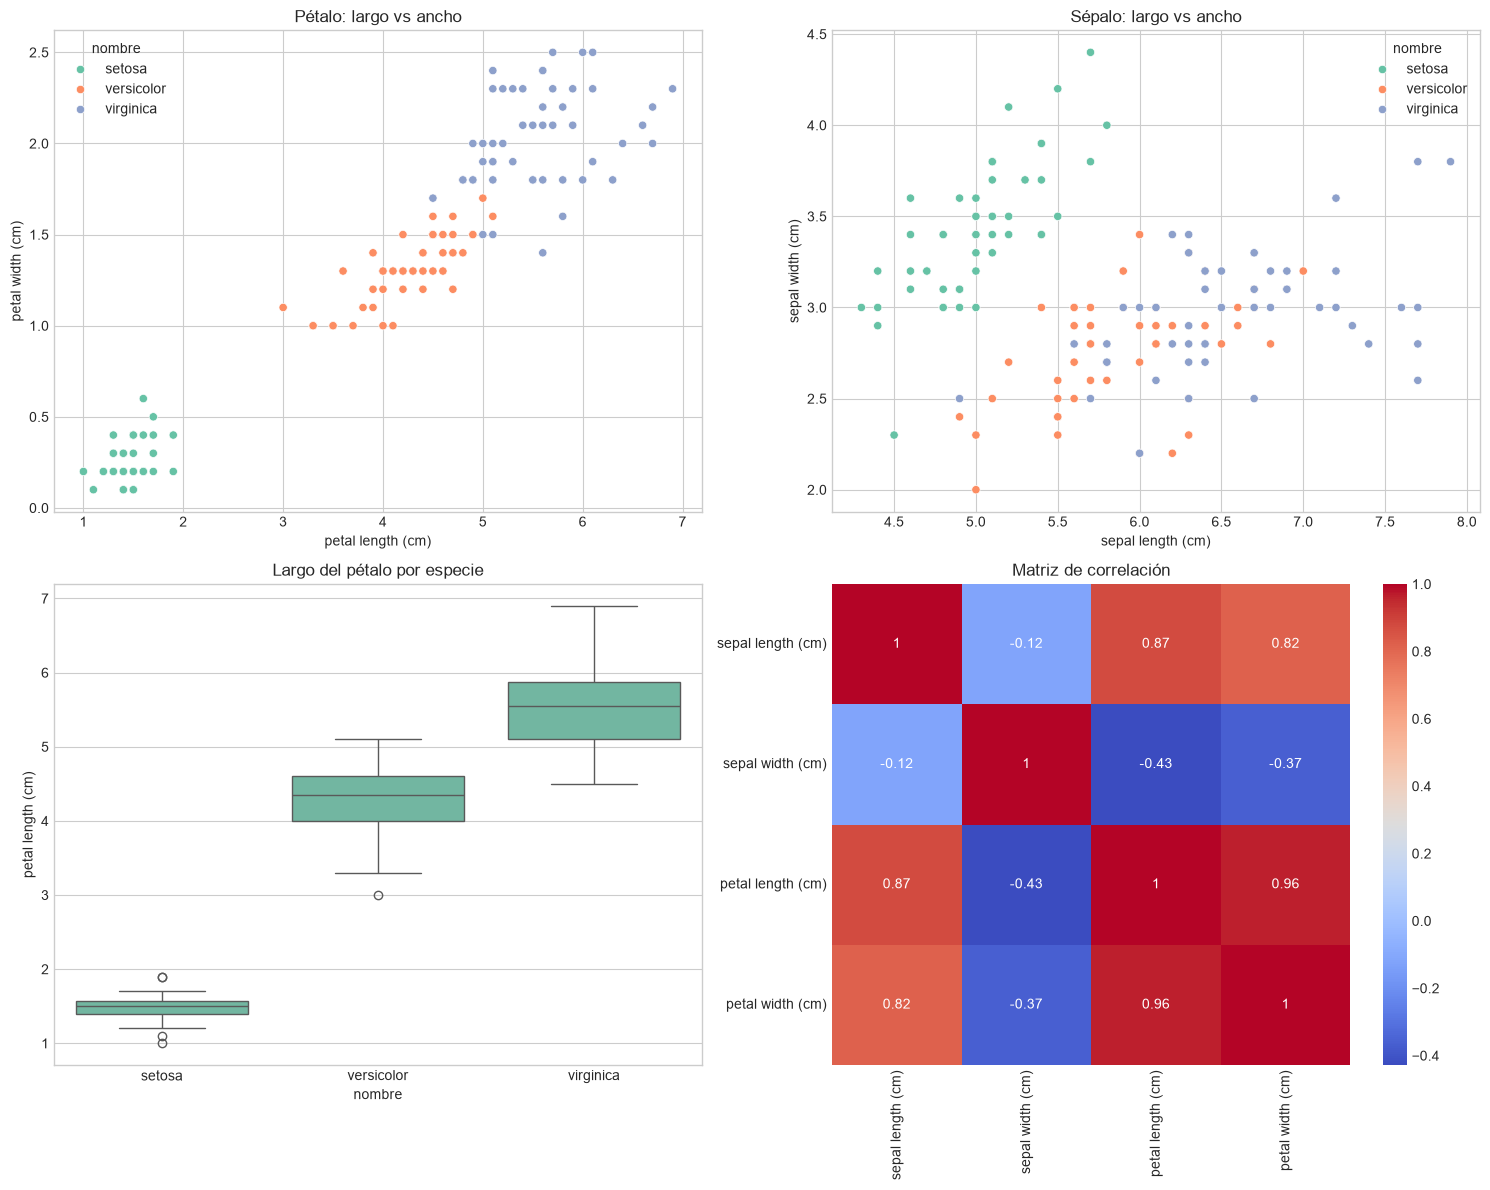

In [ ]:
# Añado el nombre de la especie para que se vea mejor en las graficas
nombres = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['nombre'] = df['species'].map(nombres)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='nombre', ax=axes[0, 0])
axes[0, 0].set_title('Pétalo: largo vs ancho')

sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', hue='nombre', ax=axes[0, 1])
axes[0, 1].set_title('Sépalo: largo vs ancho')

sns.boxplot(data=df, x='nombre', y='petal length (cm)', ax=axes[1, 0])
axes[1, 0].set_title('Largo del pétalo por especie')

sns.heatmap(df[dataset.feature_names].corr(), annot=True, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Matriz de correlación')

plt.tight_layout()
plt.show()

'''
Observaciones:
- Setosa se separa muy fácil de las otras dos solo con las medidas del pétalo
- Versicolor y virginica se solapan un poco
- Largo y ancho del pétalo estan muy correlacionados (0.96), y tambien con el largo del sépalo
- El ancho del sépalo es la que menos ayuda a separar las especies

'''

## 🔀 Paso 4: Preparar los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [5]:
X = df[dataset.feature_names]
y = df['species']

# 80% train y 20% test, con stratify para que haya las mismas clases en los dos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print()
print("Clases en train:")
print(y_train.value_counts())
print("Clases en test:")
print(y_test.value_counts())

Train: (120, 4)
Test: (30, 4)

Clases en train:
species
0    40
2    40
1    40
Name: count, dtype: int64
Clases en test:
species
0    10
2    10
1    10
Name: count, dtype: int64


## 🌳 Paso 5: Entrenar Árbol de Decisión con MLflow

Ahora entrenaremos un modelo de **Decision Tree** y registraremos todo con MLflow.

### 🔑 Hiperparámetros del Árbol de Decisión

- **max_depth**: Profundidad máxima del árbol (evita overfitting)
- **max_features**: Número máximo de características a considerar por split
- Valores más altos = modelo más complejo = mayor riesgo de overfitting

2026/10/02 12:08:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:08:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:08:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

Accuracy train: 0.983
Accuracy test: 0.967
Precision test: 0.97
Recall test: 0.967
F1 test: 0.967
CV accuracy: 0.933 +- 0.02

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



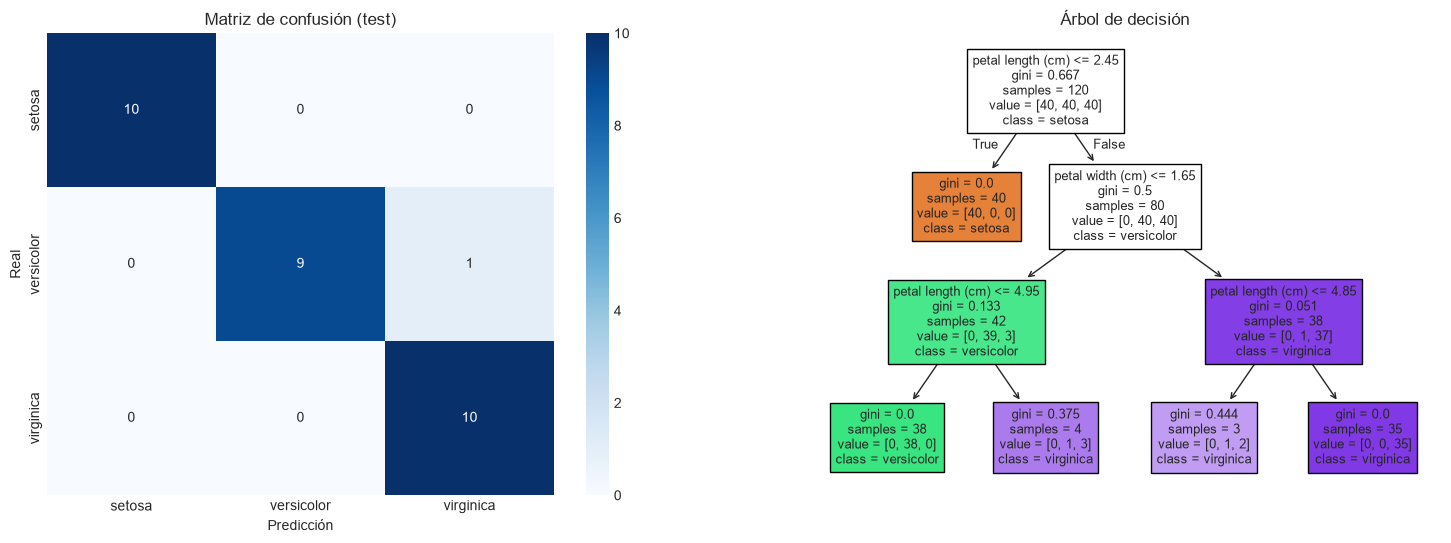

In [ ]:
mlflow.sklearn.autolog()

with mlflow.start_run(run_name="Decision Tree - Iris Classifier") as run:
    max_depth = 3
    max_features = 4
    random_state = 42

    dt = DecisionTreeClassifier(max_depth=max_depth, max_features=max_features, random_state=random_state)
    dt.fit(X_train, y_train)

    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)

    # como hay 3 clases uso average='macro'
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average='macro')
    recall_test = recall_score(y_test, y_pred_test, average='macro')
    f1_test = f1_score(y_test, y_pred_test, average='macro')

    cv_scores = cross_val_score(dt, X_train, y_train, cv=5)

    # autolog solo guarda las metricas de train, las de test y cv las meto yo
    mlflow.log_metric("accuracy_train", accuracy_train)
    mlflow.log_metric("accuracy_test", accuracy_test)
    mlflow.log_metric("precision_test", precision_test)
    mlflow.log_metric("recall_test", recall_test)
    mlflow.log_metric("f1_test", f1_test)
    mlflow.log_metric("cv_accuracy_media", cv_scores.mean())
    mlflow.log_metric("cv_accuracy_std", cv_scores.std())

    print("Accuracy train:", round(accuracy_train, 3))
    print("Accuracy test:", round(accuracy_test, 3))
    print("Precision test:", round(precision_test, 3))
    print("Recall test:", round(recall_test, 3))
    print("F1 test:", round(f1_test, 3))
    print("CV accuracy:", round(cv_scores.mean(), 3), "+-", round(cv_scores.std(), 3))
    print()
    print(classification_report(y_test, y_pred_test, target_names=dataset.target_names))

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=dataset.target_names, yticklabels=dataset.target_names, ax=axes[0])
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    axes[0].set_title('Matriz de confusión (test)')

    plot_tree(dt, feature_names=dataset.feature_names, class_names=dataset.target_names, filled=True, ax=axes[1])
    axes[1].set_title('Árbol de decisión')
    plt.show()

    mlflow.log_figure(fig, "confusion_y_arbol.png")

'''
Interpretación:
El árbol acierta 29 de 30 flores en test (accuracy 0.967). Solo falla una versicolor que predice como una virginica,
que es lo esperado viendo las graficas. Setosa la clasiica perfecta.
La diferencia entre train (0.983) y test es pequeña, asi que con max_depth=3 no parece que haya overfitting.
En CV sale algo menos (0.933), con tan pocos datos el resultado cambia bastante segun como se partan.

'''

## 🎯 Reflexión del Ejercicio

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [x] Exploración del dataset Iris
2. [x] Separación train/test
3. [x] Entrenamiento de un Árbol de Decisión
4. [x] Evaluación con métricas de clasificación
5. [x] Registro del experimento en MLflow
6. [x] Interpretación de resultados

---

## 📚 Conceptos Clave - Clasificación

### 🎯 Métricas de Clasificación

| Métrica | Descripción | Cuándo Usarla |
|---------|-------------|---------------|
| **Accuracy** | % de predicciones correctas | Clases balanceadas |
| **Precision** | % de positivos correctos | Importante evitar falsos positivos |
| **Recall** | % de positivos encontrados | Importante encontrar todos los positivos |
| **F1-Score** | Media armónica de P y R | Balance entre precisión y recall |

### 🌳 Árbol de Decisión

- **Ventajas:** es fácil de entender porque se puede dibujar y ver qué reglas usa (por ejemplo, si el pétalo mide menos de 2.5 cm es setosa). Además no hace falta escalar los datos y entrena muy rápido.
- **Overfitting:** si lo dejas crecer sin límite acaba memorizando el train (en el desafío 1 con max_depth 10 o None llega a 1.0 en train pero no mejora en test). Por eso hay que limitar max_depth o min_samples_split.
- **Matriz de confusión multiclase:** las filas son la clase real y las columnas la predicha. La diagonal son los aciertos y lo que queda fuera indica qué clase se confunde con cuál. Aquí solo hay un error, una versicolor predicha como virginica.

---

## 🚀 Desafíos Adicionales

### 🎯 Desafío 1: Optimiza los Hiperparámetros

Prueba diferentes configuraciones y encuentra la mejor:

```python
# Experimenta con:
max_depth = [3, 5, 10, None]
max_features = [2, 3, 4, 'sqrt']
min_samples_split = [2, 5, 10]
```

Las de profundidad baja (max_depth=3) son las que mejor van. Con más profundidad el train llega a 1.0 pero el test se queda en 0.93, o sea que empieza a sobreajustar. El GridSearch también elige un árbol pequeño (max_depth=2, max_features=2) con 0.967 en CV. Me quedaría con max_depth 2-3, que además es más fácil de interpretar.

### 🎯 Desafío 2: Implementa Grid Search

Automatiza la búsqueda del mejor modelo con `GridSearchCV`.

### 🎯 Desafío 3: Compara con Otros Modelos

Entrena y compara Random Forest, SVM, KNN o Logistic Regression.

### 🎯 Desafío 4: Análisis de Errores

Versicolor y virginica. En la validación cruzada hay 4 errores y todos son entre esas dos (2 y 2), setosa nunca falla. Es lógico porque en las gráficas sus pétalos tienen tamaños parecidos y se solapan. La que falla en test es una versicolor con el pétalo bastante grande (5.0 x 1.7), justo en la frontera.

### 🎯 Desafío 5: Reducción de Dimensionalidad

Usa PCA para reducir a 2 dimensiones y visualizar límites de decisión.


2026/10/02 12:09:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:09:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:09:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

   max_depth max_features  min_samples_split  acc_train  acc_test        cv
0        3.0            2                  2   0.966667  0.933333  0.966667
1        3.0            4                  5   0.983333  0.966667  0.933333
2        5.0            3                  2   1.000000  0.933333  0.950000
3        5.0         sqrt                 10   0.983333  0.933333  0.958333
4       10.0            4                  2   1.000000  0.933333  0.941667
5        NaN            4                  2   1.000000  0.933333  0.941667


2026/10/02 12:13:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:13:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:13:13 INFO mlflow.sklearn.utils: Logging the 5 best runs, 40 runs will be omitted.
2026/10/02 12:13:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle f

Mejores parámetros: {'max_depth': 2, 'max_features': 2, 'min_samples_split': 2}
Mejor accuracy en CV: 0.967
Accuracy en test: 0.933


2026/10/02 12:13:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:13:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:13:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

                modelo  accuracy_test   f1_test  cv_accuracy
2                  SVM       0.966667  0.966583     0.975000
3                  KNN       1.000000  1.000000     0.975000
4  Logistic Regression       0.966667  0.966583     0.966667
1        Random Forest       0.900000  0.899749     0.950000
0        Decision Tree       0.966667  0.966583     0.933333
Flores mal clasificadas en test: 1
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
77                6.7               3.0                5.0               1.7   

        nombre prediccion  
77  versicolor  virginica  

Errores en CV (todo el dataset): 4
predicho    setosa  versicolor  virginica
real                                     
setosa          50           0          0
versicolor       0          48          2
virginica        0           2         48


2026/10/02 12:15:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/02 12:15:43 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/10/02 12:15:47 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2026/10/02 12:15:47 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '8d6e0532dbc34160b6d1b93dc5aa76c7', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current skle

Varianza explicada por las 2 componentes: [0.925 0.053]


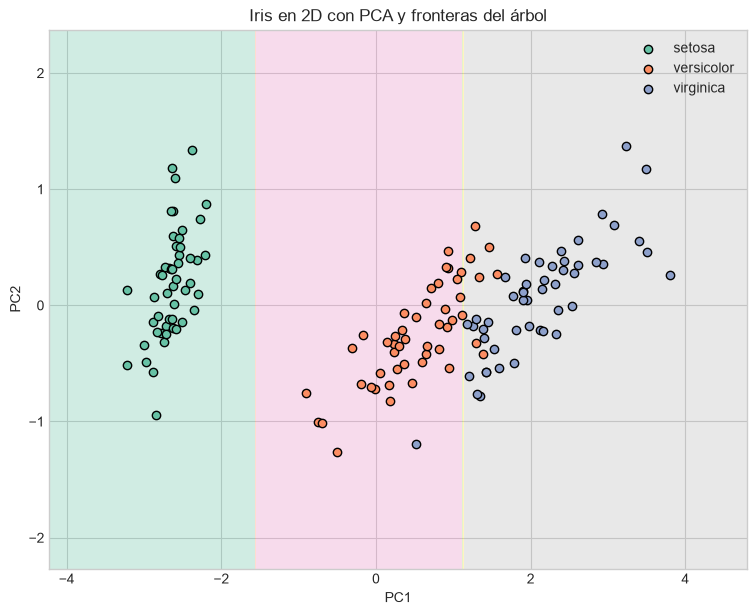

In [7]:
# 🎨 DESAFÍOS OPCIONALES

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ========================================
# DESAFÍO 1 - Optimización manual
# ========================================
configuraciones = [
    {'max_depth': 3, 'max_features': 2, 'min_samples_split': 2},
    {'max_depth': 3, 'max_features': 4, 'min_samples_split': 5},
    {'max_depth': 5, 'max_features': 3, 'min_samples_split': 2},
    {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 10},
    {'max_depth': 10, 'max_features': 4, 'min_samples_split': 2},
    {'max_depth': None, 'max_features': 4, 'min_samples_split': 2},
]

resultados_d1 = []
for config in configuraciones:
    with mlflow.start_run(run_name=f"DT depth={config['max_depth']} feat={config['max_features']} split={config['min_samples_split']}"):
        modelo = DecisionTreeClassifier(random_state=42, **config)
        modelo.fit(X_train, y_train)
        acc_train = accuracy_score(y_train, modelo.predict(X_train))
        acc_test = accuracy_score(y_test, modelo.predict(X_test))
        cv = cross_val_score(modelo, X_train, y_train, cv=5).mean()
        mlflow.log_metric("accuracy_train", acc_train)
        mlflow.log_metric("accuracy_test", acc_test)
        mlflow.log_metric("cv_accuracy_media", cv)
        resultados_d1.append({**config, 'acc_train': acc_train, 'acc_test': acc_test, 'cv': cv})

print(pd.DataFrame(resultados_d1))

# ========================================
# DESAFÍO 2 - Grid Search
# ========================================
param_grid = {
    'max_depth': [2, 3, 4, 5, None],
    'max_features': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
}

with mlflow.start_run(run_name="DT GridSearch"):
    grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    acc_test_grid = accuracy_score(y_test, grid_search.predict(X_test))
    mlflow.log_metric("accuracy_test", acc_test_grid)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor accuracy en CV:", round(grid_search.best_score_, 3))
print("Accuracy en test:", round(acc_test_grid, 3))

# ========================================
# DESAFÍO 3 - Comparación de modelos
# ========================================
modelos = {
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000),
}

resultados = []
for nombre, modelo in modelos.items():
    with mlflow.start_run(run_name=f"Comparacion - {nombre}"):
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        acc = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred, average='macro')
        cv = cross_val_score(modelo, X_train, y_train, cv=5).mean()
        mlflow.log_metric("accuracy_test", acc)
        mlflow.log_metric("f1_test", f1)
        mlflow.log_metric("cv_accuracy_media", cv)
        resultados.append({'modelo': nombre, 'accuracy_test': acc, 'f1_test': f1, 'cv_accuracy': cv})

print(pd.DataFrame(resultados).sort_values('cv_accuracy', ascending=False))

# ========================================
# DESAFÍO 4 - Análisis de errores
# ========================================
incorrect_indices = y_test.index[y_test != y_pred_test]
print("Flores mal clasificadas en test:", len(incorrect_indices))
errores = df.loc[incorrect_indices, dataset.feature_names + ['nombre']].copy()
errores['prediccion'] = [nombres[p] for p in dt.predict(X_test.loc[incorrect_indices])]
print(errores)

# Tambien miro los errores en la validacion cruzada para tener mas casos
from sklearn.model_selection import cross_val_predict
pred_cv = cross_val_predict(DecisionTreeClassifier(max_depth=3, random_state=42), X, y, cv=5)
print()
print("Errores en CV (todo el dataset):", (pred_cv != y).sum())
print(pd.crosstab(y.map(nombres), pd.Series(pred_cv).map(nombres), rownames=['real'], colnames=['predicho']))

# ========================================
# DESAFÍO 5 - PCA y visualización 2D
# ========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("Varianza explicada por las 2 componentes:", pca.explained_variance_ratio_.round(3))

# Entreno un arbol con las 2 componentes para poder pintar las fronteras
dt_pca = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pca.fit(X_pca, y)

xx, yy = np.meshgrid(np.linspace(X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1, 300),
                     np.linspace(X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1, 300))
Z = dt_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set2')
for clase in [0, 1, 2]:
    plt.scatter(X_pca[y == clase, 0], X_pca[y == clase, 1], label=nombres[clase], edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Iris en 2D con PCA y fronteras del árbol')
plt.legend()
plt.show()